# Hierarchical Fragment Linking + XGBoost Connection Filter

Runs the seed-graph → A* pipeline on a single sample, then uses a trained XGBoost
model to accept or reject each candidate connection before assembling the final graph.

**Pipeline**:
1. Load images & apply `SkinAnalysisPipeline` preprocessing
2. Build skeleton → seed graph
3. Train XGBoost from pre-generated datasets (or load saved model)
4. A* path-finding with XGB classification filter
5. Visualise result graph

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
import cv2

import skimage as ski
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from scipy.spatial import KDTree
from skimage.measure import label, regionprops


from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.core.evaluation import (
    GraphPointExtractor,
    extract_graph_points,
    compute_average_hausdorff_distance,
    compute_point_min_distances,
)

## 2. Config

In [2]:
DATASET_DIR = Path('/home/pony/projects/ienf_q/data/datasets')
DATA_DIR    = Path('/home/pony/projects/ienf_q/data_0320')

FEATURES = [
    'distance', 'normalized_cost', 'tortuosity',
    'mean_intensity', 'max_intensity', 'min_intensity', 'median_intensity',
    'std_intensity', 'intensity_q25', 'intensity_q75',
    'frac_bright', 'endpoint_intensity', 'max_deviation',
]

# SAMPLE_IDS = sorted(
#     p.stem.removeprefix('dataset_')
#     for p in DATASET_DIR.glob('dataset_*.csv')
#     if not p.stem.endswith('_paths')
#     and (DATASET_DIR / f"{p.stem}_paths.pkl").exists()
# )
SAMPLE_ID = "S1585-2_a"


# Seed graph
SEGMENT_LENGTH = 3

# A* search
SEARCH_RADIUS        = 100
BBOX_PADDING         = 10


PATH_FINDING_BBOX_PADDING = 10
HAUSDORFF_INF_SENTINEL = 10**10
HAUSDORFF_IN_LABEL_TOLERANCE = 10
XGB_PROBA_THRESHOLD = 0.5
BRIGHT_THRESHOLD = 128  # for frac_bright feature

## 3. Load / Train XGBoost Model

In [ ]:
def extract_path_features(path, orig_img, threshold=128):
    """Extract image-based features along an A* path."""
    pts = np.array(path)
    intensities = orig_img[pts[:, 0], pts[:, 1]].astype(np.float32)

    # Max perpendicular deviation from the straight line connecting endpoints
    start, end = pts[0].astype(float), pts[-1].astype(float)
    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    if line_len > 0:
        max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))
    else:
        max_deviation = 0.0

    return {
        # Intensity statistics
        'mean_intensity':     float(np.mean(intensities)),
        'max_intensity':      float(np.max(intensities)),
        'min_intensity':      float(np.min(intensities)),
        'median_intensity':   float(np.median(intensities)),
        'std_intensity':      float(np.std(intensities)),
        'intensity_q25':      float(np.percentile(intensities, 25)),
        'intensity_q75':      float(np.percentile(intensities, 75)),
        'frac_bright':        float(np.mean(intensities > threshold)),
        'endpoint_intensity': float((intensities[0] + intensities[-1]) / 2),
        # Path shape
        'max_deviation':      max_deviation,
    }

def compute_path_hausdorff_sum(path: list, gt_kdtree: KDTree) -> float:
    """Sum of min distances from each path point to the nearest GT pixel."""
    path_pts = np.array(path)
    dists, _ = gt_kdtree.query(path_pts)
    return float(np.sum(dists))

def load_and_featurize(sample_id, data_dir, threshold=128):
    img_path = data_dir / sample_id / 'image.png'

    orig_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    orig_green = cv2.split(orig_bgr)[1]  # BGR → green channel (index 1)
    annotation_img = cv2.imread(
        str(data_dir / sample_id / "annotation.png"), cv2.IMREAD_GRAYSCALE
    )
    label_img = cv2.imread(str(data_dir / sample_id / "label.png"), cv2.IMREAD_GRAYSCALE)

    if annotation_img is None:
        raise FileNotFoundError(f"Cannot read annotation.png in {data_dir / sample_id}")
    if label_img is None:
        raise FileNotFoundError(f"Cannot read label.png in {data_dir / sample_id}")

    h, w = annotation_img.shape

    # Build full-image mask (no mask.png in this dataset)
    mask_path = data_dir / sample_id / "mask.png"
    epidermis_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
        
    orig_img = cv2.imread(str(img_path), cv2.IMREAD_COLOR_RGB)
    orig_img = np.array(orig_img)[:, :, 1]  # green channel
        
    sample_pipeline = SkinAnalysisPipeline()
    sample_pipeline.config.threshold.use_full_roi = False
    final_annotation, roi_image, roi_mask = sample_pipeline.run(
        annotation_img, epidermis_mask, orig_green
    )
    topology_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    seed_graph = topology_builder.build_seed_graph(final_annotation, roi_image)

    for u, v, data in seed_graph.edges(data=True):
        data["weight"] = 1e-5

    topology_points = np.array(list(seed_graph.nodes()))
    kdtree = KDTree(topology_points)

    # 必須與訓練資料完全一致：raw green channel + 指數 8
    cost_map = ((255 - roi_image.astype(np.float64)) / 255.0) ** 8

    seed_map = np.zeros_like(cost_map, dtype=np.uint8)
    for p in topology_points:
        seed_map[p[0], p[1]] = True

    binary = (final_annotation > 0).astype(np.uint8)
    comp_map = label(binary, connectivity=2)

    path_finder = PathFinder(cost_map=cost_map)

    path_lookup = path_finder.find_paths_from_seeds(
        topology_points=topology_points,
        kdtree=kdtree,
        search_radius=SEARCH_RADIUS,
        seed_map=seed_map,
        label_img=comp_map,
    )

    
    all_samples = {}
    roi_label = cv2.bitwise_and(label_img, label_img, mask=roi_mask)
    label_binary = roi_label > 0

    gt_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    gt_graph   = gt_builder.build_seed_graph(roi_label)
    extractor = GraphPointExtractor(remove_duplicates=True)
    gt_kdtree  = KDTree(extractor.extract_points(gt_graph, include_nodes=False, include_edge_paths=True))

    for (u, v), (path, cost) in path_lookup.items():
        path_pts = np.array(path)
        path_in_label = label_binary[path_pts[:, 0], path_pts[:, 1]]
        hausdorff_sum = compute_path_hausdorff_sum(path, gt_kdtree)
        if (
            not np.all(path_in_label)
            and hausdorff_sum > HAUSDORFF_IN_LABEL_TOLERANCE
        ):
            hausdorff_sum = HAUSDORFF_INF_SENTINEL

        distance = float(np.linalg.norm(np.array(u) - np.array(v)))
        pth_arr = np.array(path)
        # calculate path length as sum of Euclidean distances between consecutive points
        path_length = float(np.sum(np.linalg.norm(np.diff(pth_arr, axis=0), axis=1)))
        normalized_cost = float(cost / max(path_length, 1e-8))
    
        all_samples[u,v] = {
                "pair_id": f"{sample_id}_{u[0]}_{u[1]}_{v[0]}_{v[1]}",
                "image_id": sample_id,
                "seed1_y": u[0],
                "seed1_x": u[1],
                "seed2_y": v[0],
                "seed2_x": v[1],
                "distance": distance,
                "path_length": path_length,
                "path_cost": cost,
                "normalized_cost": normalized_cost,
                "hausdorff_sum": hausdorff_sum,
                "path": path,
                "label": hausdorff_sum < HAUSDORFF_IN_LABEL_TOLERANCE,
                "tortuosity" : path_length / max(distance, 1e-8),
                **extract_path_features(path, roi_image, threshold)
            }
        

    
    return all_samples,roi_image,roi_label, seed_graph

print('Functions defined')

Functions defined


In [4]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.load_model('/home/pony/projects/ienf_q/data/datasets/xgb_connection_filter.json')

## 4. Load Images & Preprocessing

In [5]:
pairing_with_features, roi_image, label_img, seed_graph = load_and_featurize(SAMPLE_ID, DATA_DIR, threshold=BRIGHT_THRESHOLD)

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/tmp/ipykernel_311618/1777316221.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))


In [6]:
import joblib
loaded_scaler = joblib.load('scaler.joblib')

In [7]:
import networkx as nx
result_graph = nx.Graph()

for (u, v), features in pairing_with_features.items():

    s = pd.DataFrame([{k: features[k] for k in FEATURES}])[FEATURES]
    s = loaded_scaler.transform(s.values)
    prob = model.predict_proba(s)[0, 1]
    print(f"Edge ({u}, {v}) prob={prob:.4f}")
    if prob < XGB_PROBA_THRESHOLD:  # threshold can be tuned
        continue
    
    enhance_weight = ( 1 - prob ) * features['path_cost']
    result_graph.add_edge(u, v, **features, prob=prob, weight=enhance_weight)  

for edge in seed_graph.edges():
    if not result_graph.has_edge(*edge):
        result_graph.add_edge(*edge, weight=1e-5)  # add seed edges with small weight
print(f"Result graph has {result_graph.number_of_nodes()} nodes and {result_graph.number_of_edges()} edges.")


Edge ((724, 2382), (725, 2357)) prob=0.1708
Edge ((724, 2382), (733, 2430)) prob=0.0009
Edge ((724, 2382), (734, 2428)) prob=0.0008
Edge ((724, 2382), (730, 2433)) prob=0.0020
Edge ((730, 2381), (728, 2353)) prob=0.2443
Edge ((730, 2381), (725, 2357)) prob=0.1558
Edge ((730, 2381), (808, 2419)) prob=0.0002
Edge ((730, 2381), (809, 2410)) prob=0.0001
Edge ((730, 2381), (809, 2417)) prob=0.0002
Edge ((730, 2381), (809, 2414)) prob=0.0001
Edge ((730, 2381), (810, 2405)) prob=0.0002
Edge ((730, 2433), (746, 2458)) prob=0.0286
Edge ((730, 2433), (740, 2460)) prob=0.0268
Edge ((730, 2433), (743, 2459)) prob=0.0343
Edge ((734, 2428), (746, 2458)) prob=0.0057
Edge ((734, 2428), (740, 2460)) prob=0.0086
Edge ((734, 2428), (743, 2459)) prob=0.0049
Edge ((735, 2478), (732, 2471)) prob=0.9887
Edge ((735, 2478), (741, 2474)) prob=0.9934
Edge ((740, 2490), (740, 2500)) prob=0.9264
Edge ((740, 2490), (743, 2498)) prob=0.9941
Edge ((740, 2490), (746, 2500)) prob=0.9728
Edge ((746, 2500), (819, 2532)) 

In [8]:
mst = nx.minimum_spanning_tree(result_graph)

## 8. Visualisation

In [9]:
def draw_graph(ax, background, graph, edge_color='lime', node_color='cyan',
               linewidth=1.0, node_size=1.5, show_nodes=True):
    ax.imshow(background, cmap='gray' if background.ndim == 2 else None)
    for u, v, data in graph.edges(data=True):
        path = data.get('path', [u, v])
        if len(path) >= 2:
            ax.plot([p[1] for p in path], [p[0] for p in path],
                    color=edge_color, linewidth=linewidth, alpha=0.85)
    if show_nodes:
        for node in graph.nodes():
            ax.plot(node[1], node[0], '.', color=node_color, markersize=node_size)

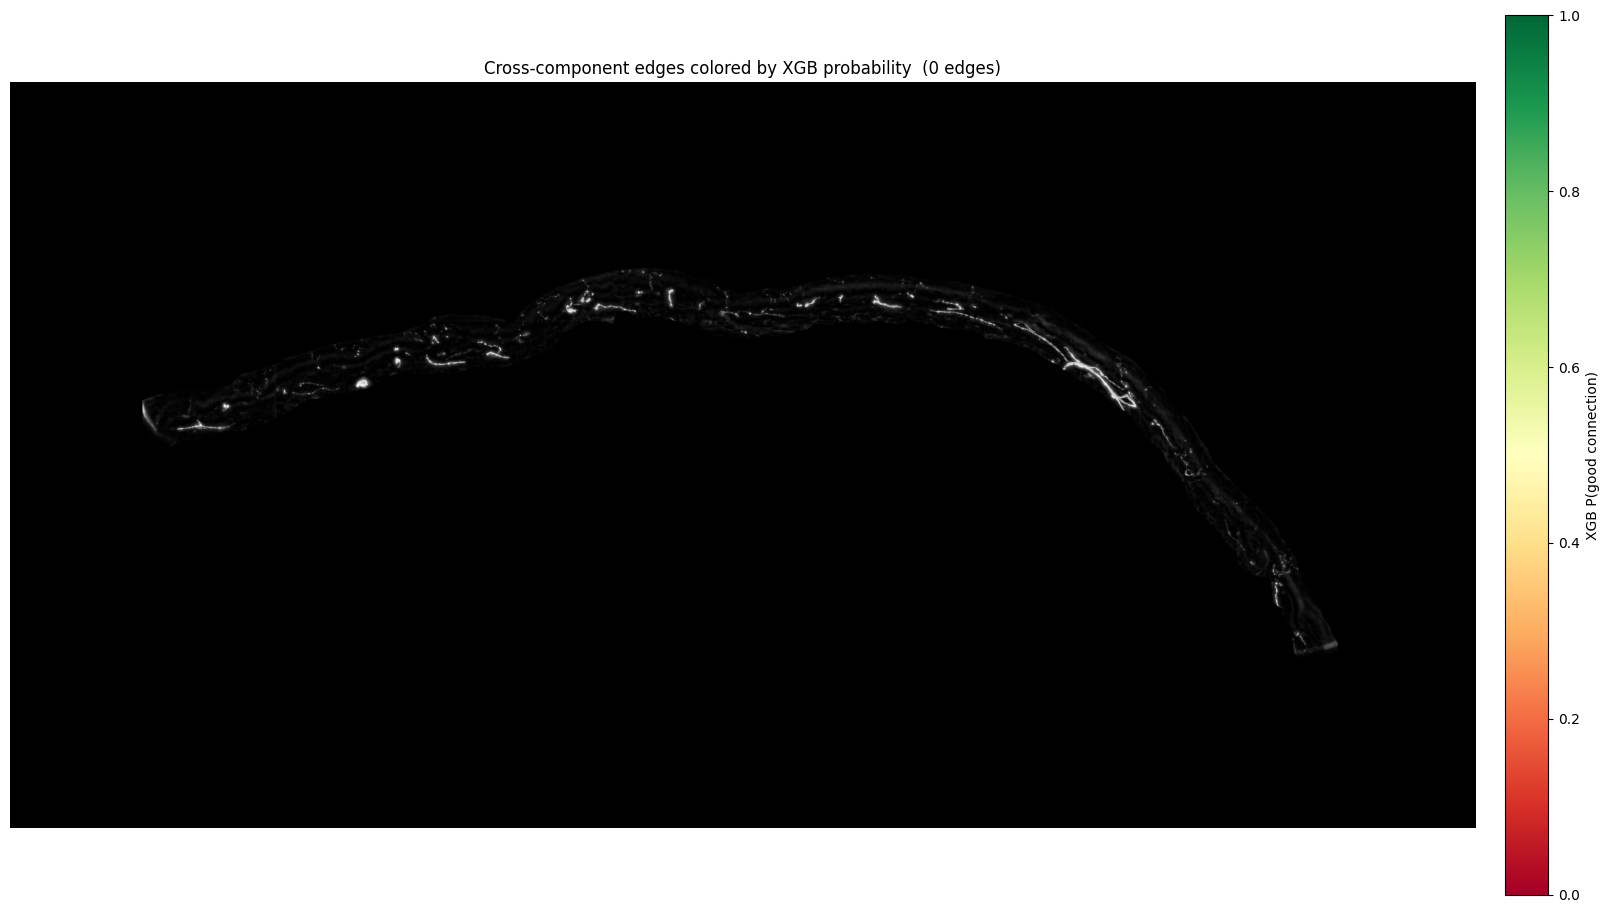

In [10]:
# Color edges by XGB acceptance probability
cross_edges = [(u, v, d) for u, v, d in result_graph.edges(data=True)
               if d.get('proba', 1.0) < 1.0]  # exclude intra-fragment edges

probas = [d['proba'] for _, _, d in cross_edges]
cmap_p = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)
ax.imshow(roi_image, cmap='gray')

for u, v, data in cross_edges:
    path  = data.get('path', [u, v])
    color = cmap_p(data['proba'])
    if len(path) >= 2:
        ax.plot([p[1] for p in path], [p[0] for p in path],
                color=color, linewidth=1.5, alpha=0.9)

sm = plt.cm.ScalarMappable(cmap=cmap_p, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='XGB P(good connection)', fraction=0.03, pad=0.02)
ax.set_title(f'Cross-component edges colored by XGB probability  ({len(cross_edges)} edges)')
ax.axis('off')
plt.show()

if probas:
    plt.figure(figsize=(7, 4))
    plt.hist(probas, bins=30, color='steelblue', edgecolor='white')
    plt.axvline(XGB_PROBA_THRESHOLD, color='red', linestyle='--', label=f'threshold={XGB_PROBA_THRESHOLD}')
    plt.xlabel('XGB Probability')
    plt.ylabel('Count')
    plt.title('Distribution of accepted edge probabilities')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
viz_img = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2RGB)

components = list(nx.connected_components(mst))
cmap_comp  = plt.cm.get_cmap('tab20', max(len(components), 1))

# fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)
# ax.imshow(roi_image, cmap='gray')

for idx, comp_nodes in enumerate(components):
    color    = cmap_comp(idx % 20)
    subgraph = mst.subgraph(comp_nodes)
    for u, v, data in subgraph.edges(data=True):
        path = data.get('path', [u, v])
        if len(path) >= 2:
            # ax.plot([p[1] for p in path], [p[0] for p in path],
            #         color=color, linewidth=1.5, alpha=0.9)
            # cv2.line(viz_img, (u[1], u[0]), (v[1], v[0]), color=(int(color[0]*255), int(color[1]*255), int(color[2]*255)), thickness=1)
            cv2.polylines(viz_img, [np.array([[p[1], p[0]] for p in path], dtype=np.int32)], isClosed=False, color=(int(color[0]*255), int(color[1]*255), int(color[2]*255)), thickness=1)
    for node in comp_nodes:
        # ax.plot(node[1], node[0], '.', color=color, markersize=2)
        cv2.circle(viz_img, (node[1], node[0]), radius=1, color=(int(color[0]*255), int(color[1]*255), int(color[2]*255)), thickness=-1)

# ax.set_title(f'Connected Components  ({len(components)} components)')
# ax.axis('off')
# plt.imshow(viz_img)
# plt.show()
cv2.imwrite('component_visualization.png', viz_img)

/tmp/ipykernel_311618/190251580.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_comp  = plt.cm.get_cmap('tab20', max(len(components), 1))


True

In [12]:
from neural_reconstruction.core.evaluation import extract_graph_points, compute_average_hausdorff_distance, compute_point_min_distances
from neural_reconstruction.core.topology import TopologyBuilder

# Build GT topology from label.png
gt_builder = TopologyBuilder()
gt_graph   = gt_builder.build_seed_graph(label_img)

pred_points = extract_graph_points(mst)
gt_points   = extract_graph_points(gt_graph)

print(f'Pred graph points : {len(pred_points)}')
print(f'GT graph points   : {len(gt_points)}')

avg_dist, d_pred_to_gt, d_gt_to_pred = compute_average_hausdorff_distance(
    pred_points, gt_points, return_components=True
)

print()
print('=== Average Hausdorff Distance ===')
print(f'Avg Hausdorff Distance : {avg_dist:.4f} px')
print(f'  Pred → GT            : {d_pred_to_gt:.4f} px')
print(f'  GT   → Pred          : {d_gt_to_pred:.4f} px')

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


Pred graph points : 5272
GT graph points   : 7882

=== Average Hausdorff Distance ===
Avg Hausdorff Distance : 3.1273 px
  Pred → GT            : 3.2453 px
  GT   → Pred          : 3.0094 px


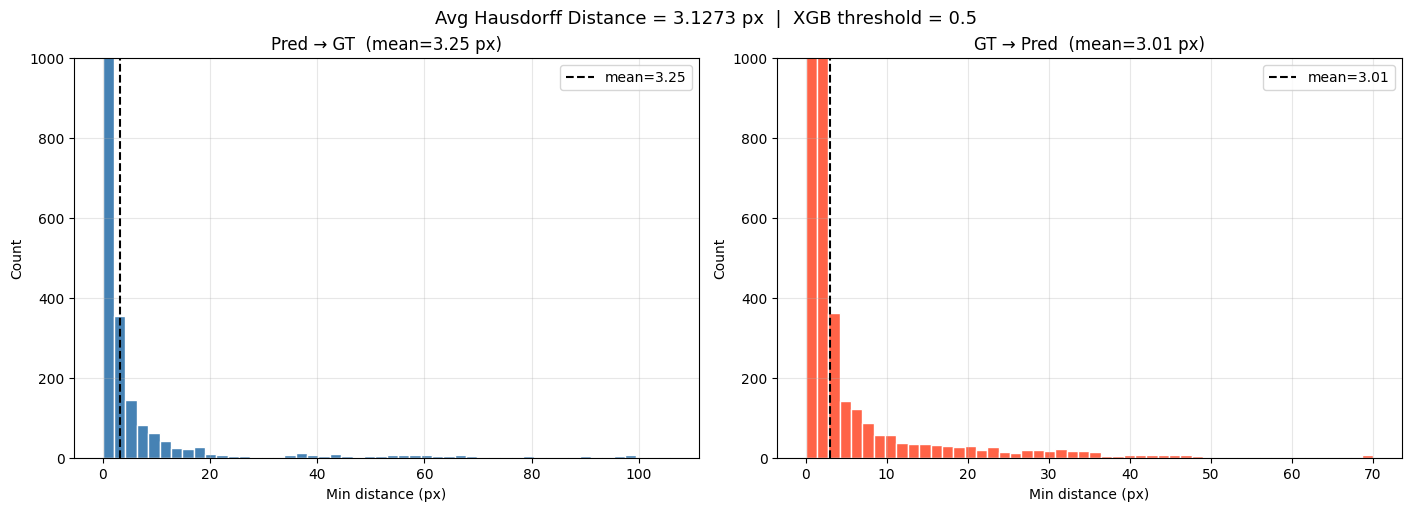

In [13]:
min_pred_to_gt, min_gt_to_pred = compute_point_min_distances(pred_points, gt_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
BINS = 50

for ax, dists, title, color in [
    (axes[0], min_pred_to_gt, f'Pred → GT  (mean={np.mean(min_pred_to_gt):.2f} px)', 'steelblue'),
    (axes[1], min_gt_to_pred, f'GT → Pred  (mean={np.mean(min_gt_to_pred):.2f} px)', 'tomato'),
]:
    ax.hist(dists, bins=BINS, color=color, edgecolor='white')
    ax.axvline(np.mean(dists), color='black', linestyle='--', label=f'mean={np.mean(dists):.2f}')
    ax.set_xlabel('Min distance (px)')
    ax.set_ylabel('Count')
    ax.set_ylim(0, 1000)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Avg Hausdorff Distance = {avg_dist:.4f} px  |  XGB threshold = {XGB_PROBA_THRESHOLD}', fontsize=13)
plt.show()